In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [5]:
file_path = r"cleaned_dataset_without_criticalcolumns.csv"
#file_path = r"cleaned_dataset.csv"
df = pd.read_csv(file_path)

In [6]:
# Determining the independent variable X, we want to use these variables to predict choice
features = [col for col in df.columns if col not in ['ID', 'Choice']]
X = df[features]

# Determining the dependent variable Y, we want to predict the choice
y = df['Choice']

# This fills in the empty columns or values, but this is not the case, because with the data cleaning all the empty columns and missing values (-1) were removed
#X = X.fillna(X.median(numeric_only=True))
#X = X.dropna(axis=1, how='all')

#mask = y.notna()
#X = X[mask]
#y = y[mask]

# Splitting the data in 20% test size and 80% training size
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling of variables 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_scaled_all = scaler.fit_transform(X)

# Defining the model 
print("\nMultinomial Logistic Regression")
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000, random_state=42)


Multinomial Logistic Regression


In [7]:
# Cross validation with accuracy scores (mean and standard deviation)
cv_scores = cross_val_score(model, X_scaled_all, y, cv=5, scoring='accuracy')
print("\nCross-Validation")
print(f"five-folder Accuracy: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f} ")

# Training the model
model.fit(X_train_scaled, y_train)

# Saving the predictions based on test data
y_pred = model.predict(X_test_scaled)

# Comparing predictions with answers
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n Test Set Evaluation")
print(f"Accuracy: {acc:.4f}")
print(f" Macro F1: {macro_f1:.4f}")

# Printing the classification report
print("\nClassification Report")

print(classification_report(y_test, y_pred))

# Overview in confusion matrix
cm = confusion_matrix(y_test, y_pred)


Cross-Validation
five-folder Accuracy: [0.82022472 0.68361582 0.66666667 0.71751412 0.68361582]
Mean Accuracy: 0.7143
Standard Deviation: 0.0555 

 Test Set Evaluation
Accuracy: 0.8146
 Macro F1: 0.6784

Classification Report
              precision    recall  f1-score   support

         0.0       0.82      0.66      0.73        56
         1.0       0.86      0.90      0.88       115
         2.0       0.33      0.57      0.42         7

    accuracy                           0.81       178
   macro avg       0.67      0.71      0.68       178
weighted avg       0.83      0.81      0.82       178



C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\fleur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in versio

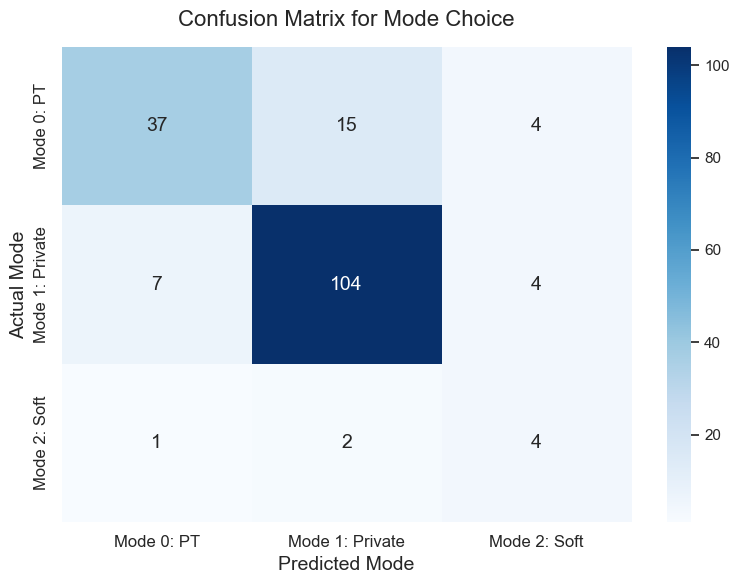

In [30]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                 xticklabels=['Mode 0: PT', 'Mode 1: Private', 'Mode 2: Soft'], 
                 yticklabels=['Mode 0: PT', 'Mode 1: Private', 'Mode 2: Soft'],
                 annot_kws={"size": 14}) 

plt.title('Confusion Matrix for Mode Choice', fontsize=16, pad=15)
plt.xlabel('Predicted Mode', fontsize=14)
plt.ylabel('Actual Mode', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
# Zorg dat feature names bestaan
feature_names = X.columns

# Coefficients ophalen
coef = model.coef_

# Dataframe maken
coef_df = pd.DataFrame(coef, columns=feature_names)

# Voeg mode labels toe
coef_df['Mode'] = model.classes_

# Zet Mode als index
coef_df = coef_df.set_index('Mode')

# Transpose (variabelen onder elkaar)
coef_df_T = coef_df.T

# on/ of to take abs values
coef_df_abs = coef_df_T.abs()

# Gemiddelde absolute impact berekenen
coef_df_abs['mean_abs_effect'] = coef_df_abs.mean(axis=1)
coef_df_abs = coef_df_abs.sort_values(by='mean_abs_effect', ascending=False)

print(coef_df_abs.head(15))

Mode                   0.0       1.0       2.0  mean_abs_effect
TimeCar           2.308972  0.565271  1.743700         1.539314
NbTrajects        0.621001  0.738785  1.359786         0.906524
InVehicleTime     0.519935  0.758598  1.278533         0.852355
WaitingTimePT     1.217683  0.280101  0.937582         0.811789
ReportedDuration  0.543828  1.037999  0.494171         0.692000
distance_km       0.201471  0.975903  0.774433         0.650602
Mobil16           0.515548  0.444062  0.959610         0.639740
TimePT            0.067115  0.854469  0.787354         0.569646
WalkingTimePT     0.335933  0.840121  0.504188         0.560080
CostCarCHF        0.315551  0.514035  0.829586         0.553057
CostCar           0.315301  0.514088  0.829389         0.552926
NbCellPhones      0.193064  0.592263  0.785328         0.523552
ResidCh03         0.592795  0.183969  0.776764         0.517843
CostPT            0.755530  0.228449  0.527081         0.503687
LangCode          0.716917  0.026343  0.

In [42]:
all_features = coef_df_T.drop(columns=['mean_abs_effect'])
all_features_sorted = all_features.loc[coef_df_T.index]

# Maak heatmap
plt.figure(figsize=(12, 18))  # groter maken want veel variabelen
sns.heatmap(all_features_sorted, cmap='coolwarm', center=0)

plt.title("Invloed van alle variabelen op vervoerskeuze", fontsize=14)
plt.xlabel("Vervoersmodus")
plt.ylabel("Variabelen")

plt.tight_layout()
plt.show()

KeyError: "['mean_abs_effect'] not found in axis"

In [20]:
groups = {
    "Socio-demographic": ['age', 'Gender', 'Education', 'BirthYear', 'LangCode', 'FamilSitu', 'NbHousehold', 'NbChild'],
    "Vehicle": ['NbCar', 'NbMoto', 'CarAvail'],
    "Spatial": ['UrbRur', 'TypeCommune', 'ClassifCodeLine', 'Region', 'frequency'],
    "Trip": ['TimePT', 'TimeCar', 'InVehicleTime', 'WalkingTimePT', 'WaitingTimePT', 
                'distance_km', 'NbTransf', 'MarginalCostPT', 'CostCar'],
    "History": ['TripPurpose', 'DestAct', 'NbTrajects', 'FreqTripHouseh', 
                      'ModeToSchool', 'ResidChild', 'FreqTrainPar', 'FreqOtherPar'],
    "Attitudes": ['Envir01', 'Envir05', 'Mobil01', 'Mobil04', 'Mobil08', 'Mobil13', 
             'Mobil15', 'Mobil23', 'ResidCh05', 'ResidCh07', 'LifSty02', 
             'LifSty06', 'LifSty08', 'LifSty11']}

group_mode_importance = {}

# Loop over groepen
for group_name, cols in groups.items():
    existing_cols = [col for col in cols if col in coef_df_T.index]
    
    # Selecteer alleen relevante features
    subset = coef_df_T.loc[existing_cols].drop(columns=['mean_abs_effect'])
    
    # Neem gemiddelde absolute waarde PER MODE
    group_mode_importance[group_name] = subset.abs().mean(axis=0)

# Omzetten naar dataframe
group_mode_df = pd.DataFrame(group_mode_importance).T

# Sorteren op totale impact (optioneel)
group_mode_df['mean_total'] = group_mode_df.mean(axis=1)
group_mode_df = group_mode_df.sort_values(by='mean_total', ascending=False)

# Drop helper kolom
group_mode_df = group_mode_df.drop(columns=['mean_total'])

print(group_mode_df)

Mode                    0.0       1.0       2.0
Trip               0.590979  0.601575  0.835485
Socio-demographic  0.310231  0.117028  0.290592
Attitudes          0.192848  0.219765  0.254832
History            0.225049  0.197111  0.240860
Vehicle            0.067783  0.260500  0.324650
Spatial            0.127305  0.135530  0.141354


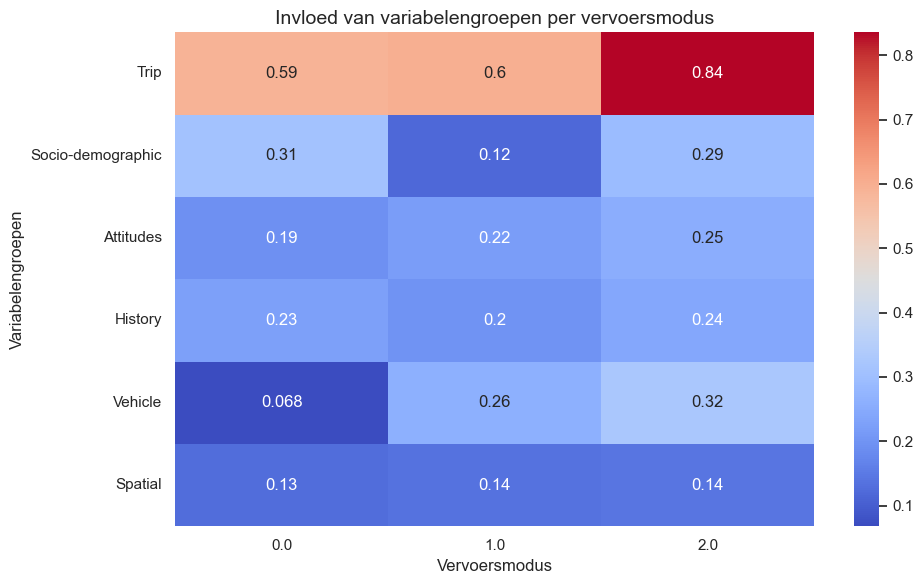

In [21]:
plt.figure(figsize=(10, 6))

sns.heatmap(group_mode_df, 
            annot=True, 
            cmap='coolwarm', 
            cbar=True)

plt.title("Invloed van variabelengroepen per vervoersmodus", fontsize=14)
plt.xlabel("Vervoersmodus")
plt.ylabel("Variabelengroepen")

plt.tight_layout()
plt.show()